# 📓 MLflow - Ejemplos básicos
# 
En esta notebook veremos ejemplos sencillos de:
- MLflow Tracking
- MLflow Projects
- MLflow Models
- MLflow Model Registry

## Instalación y configuración inicial
Instalación de MLflow (descomentar si no lo tienes instalado)
!pip install mlflow


In [1]:
# ========================
# MLflow - Ejemplos básicos
# ========================

# Instalación (si es necesario)
# !pip install mlflow

import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import os
import yaml

# Crear carpeta para artefactos si no existe
os.makedirs("outputs", exist_ok=True)


## Nombre del proyecto y url de MLFlow local

In [2]:
mlflow.set_tracking_uri("http://localhost:5000")  # o la IP donde esté el Docker
mlflow.set_experiment("Regresion lineal")

2025/11/09 21:21:33 INFO mlflow.tracking.fluent: Experiment with name 'Regresion lineal' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/961897941751127932', creation_time=1762734093643, experiment_id='961897941751127932', last_update_time=1762734093643, lifecycle_stage='active', name='Regresion lineal', tags={}>

## 🧩 1. MLflow Tracking
 
### 📄 Descripción
Con **MLflow Tracking** registramos:
 - Parámetros (por ejemplo, hiperparámetros de un modelo).
 - Métricas (precisión, error, R2, etc.).
 - Artefactos (modelos entrenados, imágenes, datasets).
 
Todo queda guardado en un historial organizado para análisis y comparación.


In [3]:
# Ejemplo sencillo de Tracking

# Datos ficticios
X, y = make_regression(n_samples=100, n_features=8, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Empezar una corrida (run)
with mlflow.start_run(run_name="linear_regression_example"):
    # Modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Parámetro (en este caso no hay hiperparámetros, así que lo simulamos)
    mlflow.log_param("model_type", "LinearRegression")
    
    # Métrica
    score = model.score(X_test, y_test)
    mlflow.log_metric("r2_score", score)
    
    # Guardar el modelo
    mlflow.sklearn.log_model(model, artifact_path="model")
    
    print(f"Modelo guardado con R2: {score:.2f}")


2025/11/09 21:21:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modelo guardado con R2: 1.00
🏃 View run linear_regression_example at: http://localhost:5000/#/experiments/961897941751127932/runs/02467d6eab0a41cfb07f710746797f18
🧪 View experiment at: http://localhost:5000/#/experiments/961897941751127932


In [4]:
# Ejemplo california_housing

import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Cargar el dataset de California Housing
california = fetch_california_housing(as_frame=True)
X, y = california.data, california.target

# Crear DataFrames para las características y el objetivo
columns = california.feature_names
data = pd.DataFrame(X, columns=columns)
data['Target'] = y

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(data[columns], data['Target'], random_state=42)

# Crear DataFrames para los datos de entrenamiento y prueba
train_data = X_train.copy()
train_data['Target'] = y_train

test_data = X_test.copy()
test_data['Target'] = y_test

# Crear carpeta outputs si no existe
import os
os.makedirs("outputs", exist_ok=True)

# Guardar los datos como archivos CSV
train_data.to_csv("outputs/train_data.csv", index=False)
test_data.to_csv("outputs/test_data.csv", index=False)

print("Datos de California Housing guardados en train_data.csv y test_data.csv 🎯")


Datos de California Housing guardados en train_data.csv y test_data.csv 🎯


In [8]:
mlflow.end_run()

🏃 View run worried-bird-202 at: http://localhost:5000/#/experiments/961897941751127932/runs/adbe2abe7baa4b5d8adc16f6ec20b2fe
🧪 View experiment at: http://localhost:5000/#/experiments/961897941751127932


In [5]:
import os

if os.path.exists("outputs/train_data.csv"):
    mlflow.log_artifact("outputs/train_data.csv", artifact_path="model")
    print("El archivo train_data.csv existe.")
else:
    print("El archivo train_data.csv no existe.")


El archivo train_data.csv existe.


In [9]:

import pandas as pd
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

alpha = 0.5
with mlflow.start_run(run_name="linear_regression_with_hyperparameter"):
    
    print("Datos registrados como artefactos en MLflow 🎯")
    # Modelo con hiperparámetro (simulado)
    model = LinearRegression()
    model.fit(X_train, y_train)

    mlflow.log_artifact("./outputs/train_data.csv", artifact_path="data")
    mlflow.log_artifact("./outputs/test_data.csv", artifact_path="data")

    # Registrar el hiperparámetro
    mlflow.log_param("alpha", alpha)
    
    # Registrar métrica
    score = model.score(X_test, y_test)
    mlflow.log_metric("r2_score", score)
    
    # Guardar el modelo
    signature = infer_signature(X_test, model.predict(X_test))
    mlflow.sklearn.log_model(model, artifact_path="model", signature=signature, input_example=X_test[:8])

    
    print(f"Modelo guardado con R2: {score:.2f} y alpha: {alpha}")

Datos registrados como artefactos en MLflow 🎯


Modelo guardado con R2: 0.59 y alpha: 0.5
🏃 View run linear_regression_with_hyperparameter at: http://localhost:5000/#/experiments/961897941751127932/runs/873402ed11474da0981461466c1ca2a1
🧪 View experiment at: http://localhost:5000/#/experiments/961897941751127932


In [10]:
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from mlflow.models.signature import infer_signature

alpha = 0.5

# Verifica si los archivos existen antes de registrarlos
if os.path.exists("outputs/train_data.csv"):
    with mlflow.start_run(run_name="linear_regression_with_hyperparameter"):
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Registrar los archivos como artefactos
        mlflow.log_artifact("outputs/train_data.csv", artifact_path="data")
        mlflow.log_artifact("outputs/test_data.csv", artifact_path="data")

        # Registrar el modelo con su firma y ejemplo de entrada
        signature = infer_signature(X_test, model.predict(X_test))
        mlflow.sklearn.log_model(model, artifact_path="model", signature=signature, input_example=X_test[:8])

        # Registrar el hiperparámetro
        mlflow.log_param("alpha", alpha)

        # Registrar la métrica
        score = model.score(X_test, y_test)
        mlflow.log_metric("r2_score", score)

        print(f"Modelo guardado con R2: {score:.2f} y alpha: {alpha}")
else:
    print("El archivo de datos no está disponible.")


Modelo guardado con R2: 0.59 y alpha: 0.5
🏃 View run linear_regression_with_hyperparameter at: http://localhost:5000/#/experiments/961897941751127932/runs/9cd693a7a3fb4980844f6fea215ae24a
🧪 View experiment at: http://localhost:5000/#/experiments/961897941751127932


In [11]:
import pandas as pd
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from sklearn.linear_model import LinearRegression

# Definir hiperparámetro
alpha = 0.5

# Modelo con hiperparámetro (simulado)
model = LinearRegression()
model.fit(X_train, y_train)

# Registrar la firma y ejemplo de entrada
signature = infer_signature(X_test, model.predict(X_test))
input_example = X_test[:8]


with mlflow.start_run(run_name="linear_regression_with_hyperparameter"):
    # Logear parámetros
    mlflow.log_param("alpha", alpha)
    
    # Logear métricas
    score = model.score(X_test, y_test)
    mlflow.log_metric("r2_score", score)
    
    # Guardar el modelo bien: con firma e input_example
    mlflow.sklearn.log_model(
        model, 
        artifact_path="model",
        signature=signature,
        input_example=input_example
    )
    
    # Logear datasets
    mlflow.log_artifact("outputs/train_data.csv", artifact_path="data")
    mlflow.log_artifact("outputs/test_data.csv",  artifact_path="data")
    mlflow.log_artifact("linear_regression_model.py", artifact_path="code")

   
    print(f"Modelo guardado con R2: {score:.2f} y alpha: {alpha}")
    print("Datos registrados como artefactos en MLflow 🎯")


Modelo guardado con R2: 0.59 y alpha: 0.5
Datos registrados como artefactos en MLflow 🎯
🏃 View run linear_regression_with_hyperparameter at: http://localhost:5000/#/experiments/961897941751127932/runs/ef500a4040704460964d00edffc0ecb9
🧪 View experiment at: http://localhost:5000/#/experiments/961897941751127932


## 🧩 2. MLflow Projects
 
### 📄 Descripción
**MLflow Projects** define un estándar para empaquetar proyectos de ML, haciéndolos:
 - Reproducibles (cualquiera puede correrlo igual).
 - Ejecutables localmente o en la nube.
 - Versionables junto al código.
 
<!-- Utiliza un archivo `MLproject` (YAML) para describir dependencias y comandos de entrada. -->


In [12]:
# Creamos un archivo MLproject para definir el proyecto

project_yaml = """
name: simple_linear_regression
conda_env: conda.yaml

entry_points:
  main:
    parameters:
      alpha: {type: float, default: 0.5}
    command: "python train.py --alpha {alpha}"
"""

with open("MLproject", "w") as f:
    f.write(project_yaml)

# Creamos un entorno conda de ejemplo
conda_yaml = """
name: simple-mlflow-env
dependencies:
  - python=3.8
  - scikit-learn
  - pip
  - pip:
      - mlflow
"""

with open("conda.yaml", "w") as f:
    f.write(conda_yaml)

print("Archivo MLproject y conda.yaml creados 🎯")


Archivo MLproject y conda.yaml creados 🎯


In [32]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Define the experiment name
mlflow.set_experiment("Random_Forest_Manual_Tuning")

# Define hyperparameter ranges
n_estimators_list = [100, 200]
max_depth_list = [10, 20, None]
min_samples_split_list = [2]
i=0
# Start parent run
with mlflow.start_run(run_name="rf_parameter_tuning") as parent_run:
    mlflow.log_param("algorithm", "RandomForest")
    
    best_score = 0
    best_params = {}
    best_model = None

    # Nested runs for each parameter combination
    for n_estimators in n_estimators_list:
        for max_depth in max_depth_list:
            for min_samples_split in min_samples_split_list:
                with mlflow.start_run(run_name=f"rf_trial{i}", nested=True):
                    # Create and train model
                    i=i+1
                    rf = RandomForestRegressor(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        random_state=42
                    )
                    
                    rf.fit(X_train, y_train)
                    
                    # Calculate scores
                    train_score = rf.score(X_train, y_train)
                    test_score = rf.score(X_test, y_test)
                    
                    # Log parameters and metrics
                    mlflow.log_params({
                        "n_estimators": n_estimators,
                        "max_depth": str(max_depth),  # Convert None to string
                        "min_samples_split": min_samples_split
                    })
                    
                    mlflow.log_metrics({
                        "train_r2": train_score,
                        "test_r2": test_score
                    })
                    
                    # Update best model if needed
                    if test_score > best_score:
                        best_score = test_score
                        best_params = {
                            "n_estimators": n_estimators,
                            "max_depth": max_depth,
                            "min_samples_split": min_samples_split
                        }
                        best_model = rf

    # Log best model and parameters in parent run
    signature = infer_signature(X_test, best_model.predict(X_test))
    mlflow.sklearn.log_model(best_model, "best_model", signature=signature)
    mlflow.log_metrics({"best_test_r2": best_score})
    mlflow.log_params({"best_" + k: str(v) for k, v in best_params.items()})
    
    print(f"Best parameters: {best_params}")
    print(f"Best test R2 score: {best_score:.3f}")

🏃 View run rf_trial0 at: http://localhost:5000/#/experiments/788859308398923334/runs/fa415d22a92a40a1972e6c590d462189
🧪 View experiment at: http://localhost:5000/#/experiments/788859308398923334
🏃 View run rf_trial1 at: http://localhost:5000/#/experiments/788859308398923334/runs/8d41516155fc4191aaffdb24a4fc685c
🧪 View experiment at: http://localhost:5000/#/experiments/788859308398923334
🏃 View run rf_trial2 at: http://localhost:5000/#/experiments/788859308398923334/runs/38f98385e1474361aa78a03cc8e7613a
🧪 View experiment at: http://localhost:5000/#/experiments/788859308398923334
🏃 View run rf_trial3 at: http://localhost:5000/#/experiments/788859308398923334/runs/28b7e8aa84604b6fb86d352a7af7a210
🧪 View experiment at: http://localhost:5000/#/experiments/788859308398923334
🏃 View run rf_trial4 at: http://localhost:5000/#/experiments/788859308398923334/runs/62de0391bf324ae0bc493eef44863972
🧪 View experiment at: http://localhost:5000/#/experiments/788859308398923334
🏃 View run rf_trial5 at: 

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Define the experiment name
mlflow.set_experiment("Random_Forest_Manual_Tuning")

# Define hyperparameter ranges
n_estimators_list = [100, 200]
max_depth_list = [10, 20, None]
min_samples_split_list = [2]
i=0
# Start parent run
with mlflow.start_run(run_name="rf_parameter_tuning") as parent_run:
    mlflow.log_param("algorithm", "RandomForest")
    
    best_score = 0
    best_params = {}
    best_model = None

    # Nested runs for each parameter combination
    for n_estimators in n_estimators_list:
        for max_depth in max_depth_list:
            for min_samples_split in min_samples_split_list:
                with mlflow.start_run(run_name=f"rf_trial{i}", nested=True):
                    # Create and train model
                    i=i+1
                    rf = RandomForestRegressor(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        random_state=42
                    )
                    
                    rf.fit(X_train, y_train)
                    
                    # Calculate scores
                    train_score = rf.score(X_train, y_train)
                    test_score = rf.score(X_test, y_test)
                    
                    # Log parameters and metrics
                    mlflow.log_params({
                        "n_estimators": n_estimators,
                        "max_depth": str(max_depth),  # Convert None to string
                        "min_samples_split": min_samples_split
                    })
                    
                    mlflow.log_metrics({
                        "train_r2": train_score,
                        "test_r2": test_score
                    })
                    
                    # Update best model if needed
                    if test_score > best_score:
                        best_score = test_score
                        best_params = {
                            "n_estimators": n_estimators,
                            "max_depth": max_depth,
                            "min_samples_split": min_samples_split
                        }
                        best_model = rf

    # Log best model and parameters in parent run
    signature = infer_signature(X_test, best_model.predict(X_test))
    mlflow.sklearn.log_model(best_model, "best_model", signature=signature)
    mlflow.log_metrics({"best_test_r2": best_score})
    mlflow.log_params({"best_" + k: str(v) for k, v in best_params.items()})
    
    print(f"Best parameters: {best_params}")
    print(f"Best test R2 score: {best_score:.3f}")

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

# Entrenamiento igual que arriba
mlflow.set_experiment("Random_Forest_Manual_Tuning_ROC")

n_estimators_list = [100, 200]
max_depth_list = [10, 20, None]
min_samples_split_list = [2]
i = 0

with mlflow.start_run(run_name="rf_parameter_tuning_roc") as parent_run:
    mlflow.log_param("algorithm", "RandomForest")
    
    best_score = 0
    best_params = {}
    best_model = None

    for n_estimators in n_estimators_list:
        for max_depth in max_depth_list:
            for min_samples_split in min_samples_split_list:
                with mlflow.start_run(run_name=f"rf_trial{i}", nested=True):
                    i += 1
                    rf = RandomForestRegressor(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        random_state=42
                    )
                    rf.fit(X_train, y_train)
                    train_score = rf.score(X_train, y_train)
                    test_score = rf.score(X_test, y_test)
                    mlflow.log_params({
                        "n_estimators": n_estimators,
                        "max_depth": str(max_depth),
                        "min_samples_split": min_samples_split
                    })
                    mlflow.log_metrics({
                        "train_r2": train_score,
                        "test_r2": test_score
                    })
                    if test_score > best_score:
                        best_score = test_score
                        best_params = {
                            "n_estimators": n_estimators,
                            "max_depth": max_depth,
                            "min_samples_split": min_samples_split
                        }
                        best_model = rf

    # ROC curve (solo tiene sentido para clasificación, pero para regresión se puede simular con un umbral)
    # Aquí simulamos binarizando el target usando la mediana
    y_test_bin = (y_test > y_test.median()).astype(int)
    y_pred_prob = best_model.predict(X_test)
    fpr, tpr, thresholds = roc_curve(y_test_bin, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.savefig("outputs/roc_curve.png")
    plt.close()

    mlflow.log_artifact("outputs/roc_curve.png", artifact_path="charts")

    signature = infer_signature(X_test, best_model.predict(X_test))
    mlflow.sklearn.log_model(best_model, "best_model", signature=signature)
    mlflow.log_metrics({"best_test_r2": best_score, "roc_auc": roc_auc})
    mlflow.log_params({"best_" + k: str(v) for k, v in best_params.items()})

    print(f"Best parameters: {best_params}")
    print(f"Best test R2 score: {best_score:.3f}")
    print(f"ROC curve guardada y registrada en MLflow 🎯")

2025/11/09 21:55:25 INFO mlflow.tracking.fluent: Experiment with name 'Random_Forest_Manual_Tuning_ROC' does not exist. Creating a new experiment.


🏃 View run rf_trial0 at: http://localhost:5000/#/experiments/707665105987162094/runs/fc88ae80b3eb4772bbbe0df1e45f709c
🧪 View experiment at: http://localhost:5000/#/experiments/707665105987162094
🏃 View run rf_trial1 at: http://localhost:5000/#/experiments/707665105987162094/runs/4779421400c84a74ad94a561941d1096
🧪 View experiment at: http://localhost:5000/#/experiments/707665105987162094
🏃 View run rf_trial2 at: http://localhost:5000/#/experiments/707665105987162094/runs/36745543afab40e3be686facb0a3d2b4
🧪 View experiment at: http://localhost:5000/#/experiments/707665105987162094
🏃 View run rf_trial3 at: http://localhost:5000/#/experiments/707665105987162094/runs/68c46fa04d66445eb0018774fc120ce4
🧪 View experiment at: http://localhost:5000/#/experiments/707665105987162094
🏃 View run rf_trial4 at: http://localhost:5000/#/experiments/707665105987162094/runs/d1bd2a32a075492a8f711811831bcb97
🧪 View experiment at: http://localhost:5000/#/experiments/707665105987162094
🏃 View run rf_trial5 at: 

2025/11/09 21:58:04 INFO mlflow.tracking.fluent: Experiment with name 'demo-roc-plot-experiment' does not exist. Creating a new experiment.


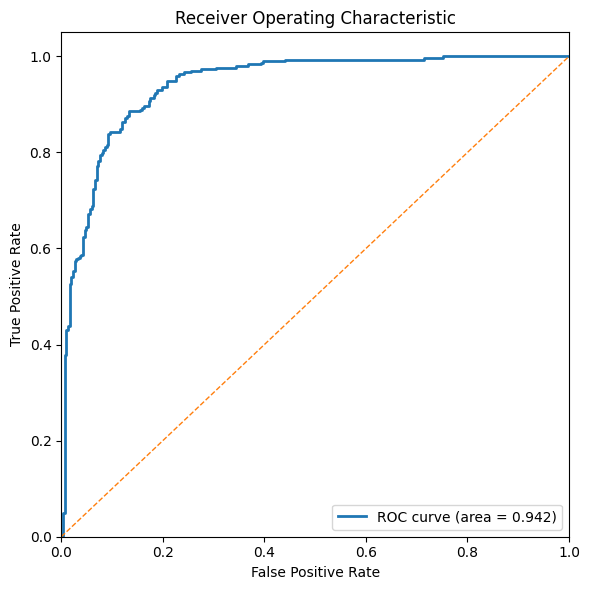

2025/11/09 21:58:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Run ID: 797bbbec9b134a0dbb10c68c07ae28f6
ROC AUC: 0.9423085470465353
🏃 View run rf-with-roc at: http://localhost:5000/#/experiments/976478245207934477/runs/797bbbec9b134a0dbb10c68c07ae28f6
🧪 View experiment at: http://localhost:5000/#/experiments/976478245207934477


In [34]:
# Notebook: MLflow + ROC curve example
# Copia y pega todo en una celda de tu notebook (o divídelo en varias celdas).
# Requisitos: mlflow, scikit-learn, matplotlib, pandas
# pip install mlflow scikit-learn matplotlib pandas

import mlflow
import mlflow.sklearn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# --- Configuración: experiment y tracking URI (opcional) ---
# Si usás el tracking server local por defecto no hace falta cambiar nada.
# mlflow.set_tracking_uri('http://your-mlflow-server:5000')
mlflow.set_experiment('demo-roc-plot-experiment')

# --- Generar datos binarios de ejemplo ---
X, y = make_classification(n_samples=2000, n_features=20, n_informative=5,
                           n_redundant=2, n_clusters_per_class=2, flip_y=0.03,
                           class_sep=1.0, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    stratify=y, random_state=42)

# --- Entrenamiento y logging con MLflow ---
with mlflow.start_run(run_name='rf-with-roc') as run:
    # Hiperparámetros
    params = {
        'n_estimators': 100,
        'max_depth': 6,
        'random_state': 42
    }
    mlflow.log_params(params)

    # Modelo
    clf = RandomForestClassifier(**params)
    clf.fit(X_train, y_train)

    # Predicciones probabilísticas
    y_proba = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)

    # Métricas
    auc_score = roc_auc_score(y_test, y_proba)
    mlflow.log_metric('roc_auc', float(auc_score))

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Crear figura matplotlib
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], linestyle='--', lw=1)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver Operating Characteristic')
    ax.legend(loc='lower right')
    plt.tight_layout()

    # Mostrar en el notebook (útil si ejecutás aquí)
    plt.show()

    # --- Loggear la figura como artifact en una carpeta 'plots' ---
    # MLflow UI detecta artefactos de imagen y suele mostrarlos en la vista del run.
    # Guardamos en la ruta 'plots/roc_curve.png' dentro de los artifacts.
    plots_dir = 'plots'
    os.makedirs(plots_dir, exist_ok=True)
    local_plot_path = os.path.join(plots_dir, 'roc_curve.png')
    fig.savefig(local_plot_path)

    # 1) Loguear la figura directamente (mlflow.log_figure agrega la figura a los artifacts)
    try:
        mlflow.log_figure(fig, 'plots/roc_curve.png')
    except Exception as e:
        # Si mlflow.log_figure no está disponible en tu versión o falla, usamos log_artifact
        mlflow.log_artifact(local_plot_path, artifact_path='plots')

    # 2) También subimos un CSV con los puntos de la curva (útil para reproducir o graficar desde UI)
    df_roc = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds})
    csv_path = 'plots/roc_points.csv'
    df_roc.to_csv(csv_path, index=False)
    mlflow.log_artifact(csv_path, artifact_path='plots')

    # Guardar y registrar modelo (opcional)
    mlflow.sklearn.log_model(clf, artifact_path='model')

    # Info del run
    run_id = run.info.run_id
    print('\nRun ID:', run_id)
    print('ROC AUC:', roc_auc)

# Fin del with mlflow.start_run

# --- Cómo verlo en MLflow UI ---
# 1) Levantá mlflow ui: mlflow ui --port 5000  (si usás server local)
# 2) Abrí http://localhost:5000 en tu navegador
# 3) Entrá al experimento 'demo-roc-plot-experiment' y abrí el run.
# 4) En la pestaña "Artifacts" deberías ver la carpeta 'plots' con 'roc_curve.png' y 'roc_points.csv'.
#    Muchas versiones de MLflow muestran las imágenes en la vista del run (Plots/Artifacts).

# Si querés que además la imagen aparezca como "plot" en la parte superior (Run chart view),
# podés:
# - Asegurarte de guardar la imagen bajo artifact_path 'plots' (como hicimos).
# - Alternativamente, convertir la figura a HTML/plotly y logearlo, pero para la mayoría de UI
#   la imagen PNG bajo 'plots' es suficiente.

# Opcional: limpiar artefactos locales temporales si no los querés mantener
# import shutil
# shutil.rmtree(plots_dir, ignore_errors=True)


In [35]:
# Ejemplo: curva ROC registrada en el Run Chart View de MLflow
# pip install mlflow scikit-learn pandas

import mlflow
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
import pandas as pd

mlflow.set_experiment("demo-roc-chart-view")

# Datos de ejemplo
X, y = make_classification(n_samples=1500, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

with mlflow.start_run(run_name="rf_roc_chart_view") as run:
    params = {"n_estimators": 100, "max_depth": 6, "random_state": 42}
    mlflow.log_params(params)

    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    mlflow.log_metric("roc_auc", auc_score)

    # 🔹 Loguear los puntos de la curva ROC como métricas
    # Esto hace que MLflow muestre la curva en el "Run Chart View"
    for i, (f, t) in enumerate(zip(fpr, tpr)):
        mlflow.log_metric("FPR", f, step=i)
        mlflow.log_metric("TPR", t, step=i)

    # Loguear también el modelo (opcional)
    mlflow.sklearn.log_model(model, "model")

    print(f"Run ID: {run.info.run_id}")
    print(f"ROC AUC: {auc_score:.4f}")


2025/11/09 22:00:05 INFO mlflow.tracking.fluent: Experiment with name 'demo-roc-chart-view' does not exist. Creating a new experiment.
2025/11/09 22:00:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run ID: 609e6183af3546fa8e825ff36b58b706
ROC AUC: 0.9816
🏃 View run rf_roc_chart_view at: http://localhost:5000/#/experiments/334765765310187339/runs/609e6183af3546fa8e825ff36b58b706
🧪 View experiment at: http://localhost:5000/#/experiments/334765765310187339


In [36]:
# Ejemplo: Nested Runs en MLflow para comparar curvas ROC
# Cada sub-run usa distintos hiperparámetros y loguea su curva ROC como métricas
# pip install mlflow scikit-learn pandas

import mlflow
import mlflow.sklearn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# Configurar el experimento
mlflow.set_experiment("demo-nested-roc-curves")

# Datos simulados
X, y = make_classification(n_samples=2000, n_features=15, n_informative=8,
                           random_state=42, class_sep=1.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Definir combinaciones de hiperparámetros para probar
param_grid = [
    {"n_estimators": 50, "max_depth": 4},
    {"n_estimators": 100, "max_depth": 6},
    {"n_estimators": 200, "max_depth": 8}
]

# --- Run padre ---
with mlflow.start_run(run_name="comparacion_random_forest") as parent_run:

    mlflow.log_param("tipo_experimento", "nested_roc")

    for params in param_grid:
        # --- Sub-run (nested) ---
        with mlflow.start_run(run_name=f"rf_ne{params['n_estimators']}_d{params['max_depth']}",
                              nested=True) as child_run:

            mlflow.log_params(params)

            # Entrenar modelo
            model = RandomForestClassifier(
                n_estimators=params["n_estimators"],
                max_depth=params["max_depth"],
                random_state=42
            )
            model.fit(X_train, y_train)

            # Predicciones
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_test, y_proba)
            auc_score = roc_auc_score(y_test, y_proba)

            # Loguear AUC como métrica global
            mlflow.log_metric("roc_auc", auc_score)

            # 🔹 Loguear curva ROC como métricas para el Chart View
            for i, (f, t) in enumerate(zip(fpr, tpr)):
                mlflow.log_metric("FPR", f, step=i)
                mlflow.log_metric("TPR", t, step=i)

            # Loguear modelo
            mlflow.sklearn.log_model(model, artifact_path="model")

            print(f"Sub-run: {child_run.info.run_name} | ROC AUC = {auc_score:.4f}")

    print("\nExperimento padre completado.")
    print(f"Run padre ID: {parent_run.info.run_id}")


2025/11/09 22:02:22 INFO mlflow.tracking.fluent: Experiment with name 'demo-nested-roc-curves' does not exist. Creating a new experiment.
2025/11/09 22:02:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Sub-run: rf_ne50_d4 | ROC AUC = 0.9083
🏃 View run rf_ne50_d4 at: http://localhost:5000/#/experiments/404061852526685598/runs/2680d29900ed41a29627a7ba20634237
🧪 View experiment at: http://localhost:5000/#/experiments/404061852526685598


2025/11/09 22:02:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Sub-run: rf_ne100_d6 | ROC AUC = 0.9289
🏃 View run rf_ne100_d6 at: http://localhost:5000/#/experiments/404061852526685598/runs/af16ef7895254879aeece483122279ef
🧪 View experiment at: http://localhost:5000/#/experiments/404061852526685598


2025/11/09 22:02:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Sub-run: rf_ne200_d8 | ROC AUC = 0.9400
🏃 View run rf_ne200_d8 at: http://localhost:5000/#/experiments/404061852526685598/runs/47860ffba4b1479f952bda1d631382b2
🧪 View experiment at: http://localhost:5000/#/experiments/404061852526685598

Experimento padre completado.
Run padre ID: 9cc2e306c74f477b98b0df70672b2e37
🏃 View run comparacion_random_forest at: http://localhost:5000/#/experiments/404061852526685598/runs/9cc2e306c74f477b98b0df70672b2e37
🧪 View experiment at: http://localhost:5000/#/experiments/404061852526685598


## 🧩 3. MLflow Models
 
### 📄 Descripción
**MLflow Models** permite:
 - Guardar modelos entrenados en formatos estándar.
 - Cargarlos fácilmente para predicción o despliegue.
 - Exportarlos a múltiples plataformas (Docker, REST API, mobile).

In [ ]:
# Guardamos el modelo entrenado en disco
model_path = "outputs5/linear_model"
mlflow.sklearn.save_model(model, model_path)

# Cargamos el modelo desde disco
loaded_model = mlflow.sklearn.load_model(model_path)

# Realizamos una predicción de prueba
prediction = loaded_model.predict(X_test[:2])
print("Predicción ejemplo:", prediction)


In [61]:
import requests

url = "http://127.0.0.1:5001/predict"
data = {"data": [[0.5, 1.2, 3.4, 0.1, 2.3, 0.9, 5.5, 7.3, 0.0, 4.1, 6.6, 3.3, 2.1, 1.5, 0.2]]}

resp = requests.post(url, json=data)
print(resp.json())


{'n_samples': 1, 'predictions': [0], 'probabilities': [[0.7215518843328733, 0.2784481156671267]], 'status': 'ok'}


## 🧩 4. MLflow Model Registry
 
### 📄 Descripción
**MLflow Model Registry** gestiona:
 - Versiones de modelos.
 - Etapas del ciclo de vida (Staging, Production, Archived).
 - Aprobaciones y revisiones de modelos.
 
 **Importante:** Para usarlo realmente se necesita un Tracking Server conectado a una base de datos.
 Aquí simulamos un ejemplo sencillo en local.

In [126]:
# Buscar si el experimento ya existe
experiment_name = "Model_Registry_Example"

signature = infer_signature(X_test, model.predict(X_test))
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None:
    experiment_id = mlflow.create_experiment(experiment_name)
    print(f"Experimento '{experiment_name}' creado 🎯")
else:
    experiment_id = experiment.experiment_id
    print(f"Experimento '{experiment_name}' ya existía, usando id {experiment_id} ✔️")

# Seteamos el experimento como activo
mlflow.set_experiment(experiment_name)

# Registramos el modelo
with mlflow.start_run(run_name="registry_test_run"):
    mlflow.sklearn.log_model(model, "model", signature=signature, registered_model_name="linear_regression_with_hyperparameter")



Experimento 'Model_Registry_Example' ya existía, usando id 3 ✔️


Successfully registered model 'linear_regression_with_hyperparameter'.
2025/04/27 14:41:59 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: linear_regression_with_hyperparameter, version 1


🏃 View run registry_test_run at: http://localhost:5000/#/experiments/3/runs/ec7dc8379396411db112e00e6a9e8862
🧪 View experiment at: http://localhost:5000/#/experiments/3


Created version '1' of model 'linear_regression_with_hyperparameter'.
